**Library**

In [5]:
import sys
import os
import pandas as pd
import itertools

import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings

**Load Data**

In [ ]:
# Cell 1: Persiapan Environment & Pengambilan Data (Anti-Cache Jupyter)
import sys
import os
import importlib

os.environ["DB_USER"] = "postgres"
os.environ["DB_PASS"] = "laygenda102"  
os.environ["DB_HOST"] = "localhost"
os.environ["DB_PORT"] = "5432"
os.environ["DB_NAME"] = "SeismoCluster"

# 2. SETUP PATH UNTUK IMPORT BACKEND
backend_path = os.path.abspath('../backend')
if backend_path not in sys.path:
    sys.path.append(backend_path)

# 3. FORCE RELOAD MODUL 
import app.config.database
importlib.reload(app.config.database) # PAKSA Python mereset variabel dan membaca ulang os.environ
from app.config.database import SessionLocal

import app.models.pipeline
importlib.reload(app.models.pipeline)
from app.models.pipeline import SeismoDataPipeline

# 4. EKSEKUSI PIPELINE
db = SessionLocal()
pipeline = SeismoDataPipeline()

try:
    print("Membuka koneksi PostgreSQL dan menyedot data...")
    df_raw = pipeline.load_from_db(db)
    
    print("Melakukan Transformasi dan Scaling (4 Dimensi)...")
    df_processed = pipeline.prepare_features(df_raw)
    
    # Ekstraksi fitur yang akan dimasukkan ke dalam algoritma ML
    X_scaled = df_processed[['latitude_scaled', 'longitude_scaled', 'depth_scaled', 'magnitude_scaled']].values
    print(f"Data siap dikompetisikan! Jumlah observasi: {len(X_scaled)} baris.")
    
except Exception as e:
    print(f"Terjadi kesalahan Database: {e}")
finally:
    db.close() # Menutup sesi agar database tidak memakan banyak RAM

Membuka koneksi PostgreSQL dan menyedot data...
Melakukan Transformasi dan Scaling (4 Dimensi)...
Data siap dikompetisikan! Jumlah observasi: 12490 baris.


In [11]:
# menampilkan data
X_scaled[:5]

array([[ 0.6677512 , -0.00674284,  0.12884389, -1.30799723],
       [ 0.98063134, -0.07714336,  4.02589497,  1.71455326],
       [ 1.19205471,  0.34752112, -0.37623882,  0.61544399],
       [-0.06449923,  1.07531265, -0.2556716 , -1.03321991],
       [-0.98390189, -1.66039657, -0.64404531, -0.7584426 ]])

**Uji coba K-Means**

In [7]:
warnings.filterwarnings("ignore")

# 1. SETUP MLFLOW TRACKING
# Menyambungkan notebook ke server MLflow lokal
mlflow.set_tracking_uri("http://localhost:5000")

# Membuat/Membuka "map" khusus untuk eksperimen K-Means
mlflow.set_experiment("SeismoCluster_KMeans_Tuning")

print("Memulai Hyperparameter Tuning untuk K-Means...")
print("-" * 50)

# 2. DEFINISI RENTANG HYPERPARAMETER
# Kita akan menguji pembagian zona gempa dari 3 hingga 8 cluster
K_range = [3, 4, 5, 6, 7, 8]

# 3. LOOPING EKSPERIMEN OTOMATIS (Sesuai instruksi tugas dosen)
for k in K_range:
    # Membuka satu sesi pencatatan di MLflow untuk setiap nilai K
    with mlflow.start_run(run_name=f"KMeans_K{k}"):
        
        # --- A. TRAINING MODEL ---
        # Menambahkan n_init=10 agar hasil konsisten dan solid
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        
        # --- B. EVALUASI METRIK ---
        sil_score = silhouette_score(X_scaled, labels)
        db_score = davies_bouldin_score(X_scaled, labels)
        ch_score = calinski_harabasz_score(X_scaled, labels)
        
        # --- C. LOGGING PARAMETER & METRIK KE MLFLOW ---
        # Mencatat hyperparameter yang sedang diuji
        mlflow.log_param("algorithm", "K-Means")
        mlflow.log_param("n_clusters", k)
        
        # Mencatat hasil ujian (metric)
        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("davies_bouldin_index", db_score)
        mlflow.log_metric("calinski_harabasz", ch_score)
        
        # --- D. SAVE ARTIFACT (Simpan Model Fisik) ---
        mlflow.sklearn.log_model(kmeans, "model")
        
        print(f"Selesai K={k} | Silhouette: {sil_score:.4f} | DB Index: {db_score:.4f} | CH Score: {ch_score:.1f}")

print("-" * 50)
print("Tuning K-Means Selesai! Seluruh bukti riset telah tersimpan di MLflow.")

Memulai Hyperparameter Tuning untuk K-Means...
--------------------------------------------------


  File "c:\Users\laygenda surya putra\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\laygenda surya putra\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\laygenda surya putra\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\laygenda surya putra\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
2026/05/08 08:53:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:53:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these 

Selesai K=3 | Silhouette: 0.3154 | DB Index: 1.2977 | CH Score: 4111.3
🏃 View run KMeans_K3 at: http://localhost:5000/#/experiments/1/runs/9fc5c82340e54faeaba091e73a614bdd
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/05/08 08:53:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:53:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Selesai K=4 | Silhouette: 0.3316 | DB Index: 1.0791 | CH Score: 4730.7
🏃 View run KMeans_K4 at: http://localhost:5000/#/experiments/1/runs/b687dd98e48f41f7942c8ef20f3f1a46
🧪 View experiment at: http://localhost:5000/#/experiments/1


...

Selesai K=6 | Silhouette: 0.3317 | DB Index: 1.0128 | CH Score: 4996.8
🏃 View run KMeans_K6 at: http://localhost:5000/#/experiments/1/runs/85f0bad78b994c6aacbedfb6a8dd8fdb
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/05/08 08:54:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:54:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Selesai K=7 | Silhouette: 0.3214 | DB Index: 1.0057 | CH Score: 4923.2
🏃 View run KMeans_K7 at: http://localhost:5000/#/experiments/1/runs/a7cb5c5bc79f47fea4b6fef2f0b86353
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/05/08 08:54:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:54:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Selesai K=8 | Silhouette: 0.3216 | DB Index: 1.0255 | CH Score: 4852.3
🏃 View run KMeans_K8 at: http://localhost:5000/#/experiments/1/runs/55bad7d1123d48dd95a1f6e495ef5de4
🧪 View experiment at: http://localhost:5000/#/experiments/1
--------------------------------------------------
Tuning K-Means Selesai! Seluruh bukti riset telah tersimpan di MLflow.


![Cuplikan layar 2026-05-07 112613.png](<attachment:Cuplikan layar 2026-05-07 112613.png>)

Berdasarkan analisis dari output MLflow tersebut, menghasilkan K-Means dengan (k=5). Hal ini sebelumnya juga relevan pada asumsi saat proses EDA. Di mana menghasilkan nilai k yang optimal pada K=5.
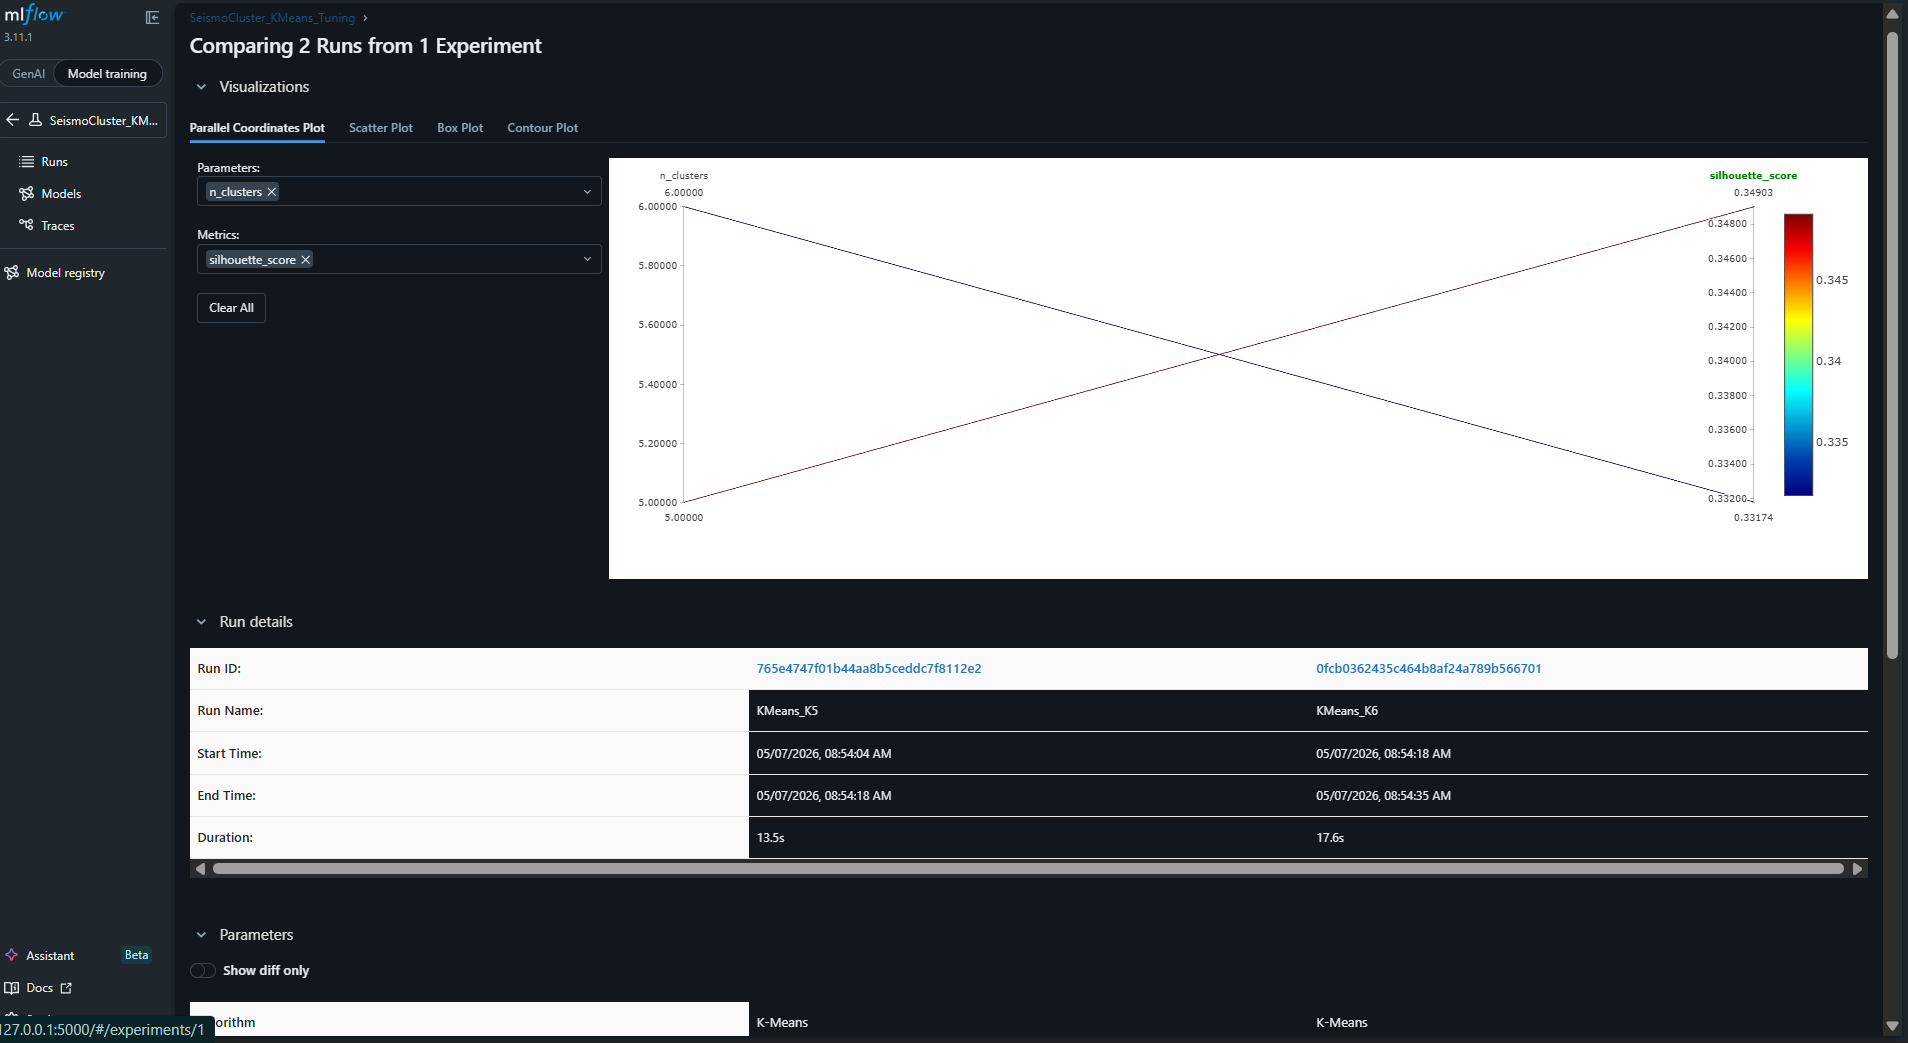

**Uji coba DBSCAN**

Melakukan otomatisasi pencarian paramater terbaik untuk eps (epsilon) dan min_samples agar model dapat membedakan antara klaster gempa yang padat dan kejadian gempa yang bersifat anomali atau terisolasi.

In [8]:
# 1. SETUP EXPERIMENT
mlflow.set_experiment("SeismoCluster_Clustering_Competition")

print("Memulai Hyperparameter Tuning untuk DBSCAN...")
print("-" * 50)

# 2. DEFINISI RUANG PARAMETER (Hyperparameter Grid)
# eps: Jarak maksimal antar dua titik untuk dianggap satu lingkungan
# min_samples: Jumlah minimum titik untuk membentuk sebuah cluster padat
param_grid = {
    "eps": [0.1, 0.15, 0.2, 0.25, 0.3],
    "min_samples": [10, 15, 20]
}

# Membuat semua kombinasi pasangan eps dan min_samples
combinations = list(itertools.product(param_grid["eps"], param_grid["min_samples"]))

# 3. LOOPING EKSPERIMEN OTOMATIS
for eps, min_samples in combinations:
    # Membuka sesi run dengan nama yang deskriptif
    with mlflow.start_run(run_name=f"DBSCAN_e{eps}_s{min_samples}"):
        
        # --- A. TRAINING MODEL ---
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        # Hitung jumlah cluster yang terbentuk (mengabaikan noise -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # --- B. EVALUASI METRIK ---
        # Catatan: Silhouette score hanya bisa dihitung jika ada minimal 2 cluster
        if n_clusters > 1:
            sil_score = silhouette_score(X_scaled, labels)
            db_score = davies_bouldin_score(X_scaled, labels)
            ch_score = calinski_harabasz_score(X_scaled, labels)
        else:
            sil_score, db_score, ch_score = 0, 0, 0
        
        # --- C. LOGGING KE MLFLOW ---
        mlflow.log_param("algorithm", "DBSCAN")
        mlflow.log_param("eps", eps)
        mlflow.log_param("min_samples", min_samples)
        
        mlflow.log_metric("n_clusters", n_clusters)
        mlflow.log_metric("n_noise", n_noise)
        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("davies_bouldin_index", db_score)
        mlflow.log_metric("calinski_harabasz", ch_score)
        
        # --- D. SAVE ARTIFACT (Log Model) ---
        mlflow.sklearn.log_model(dbscan, "model")
        
        print(f"eps={eps} | samples={min_samples} | Clusters: {n_clusters} | Noise: {n_noise} | Silh: {sil_score:.4f}")

print("-" * 50)
print("Tuning DBSCAN Selesai! Silakan bandingkan hasilnya dengan K-Means di MLflow UI.")

Memulai Hyperparameter Tuning untuk DBSCAN...
--------------------------------------------------


2026/05/08 08:54:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:54:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 08:54:26 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


eps=0.1 | samples=10 | Clusters: 94 | Noise: 9076 | Silh: -0.4332
🏃 View run DBSCAN_e0.1_s10 at: http://localhost:5000/#/experiments/2/runs/06407b25f3434040a6b57454af6ca8ab
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/08 08:54:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:54:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 08:54:35 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


eps=0.1 | samples=15 | Clusters: 50 | Noise: 10262 | Silh: -0.4457
🏃 View run DBSCAN_e0.1_s15 at: http://localhost:5000/#/experiments/2/runs/ce062e399db2487b8a9806dd15010a05
🧪 View experiment at: http://localhost:5000/#/experiments/2


...

eps=0.3 | samples=10 | Clusters: 12 | Noise: 1348 | Silh: -0.3848
🏃 View run DBSCAN_e0.3_s10 at: http://localhost:5000/#/experiments/2/runs/ce4681fa5bd84c3c86e83fba2a920c42
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/08 08:57:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:57:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 08:57:12 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


eps=0.3 | samples=15 | Clusters: 9 | Noise: 2032 | Silh: -0.2818
🏃 View run DBSCAN_e0.3_s15 at: http://localhost:5000/#/experiments/2/runs/f2ae882f21a94c15897062d220df52a5
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/08 08:57:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:57:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 08:57:24 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


eps=0.3 | samples=20 | Clusters: 5 | Noise: 2661 | Silh: -0.1102
🏃 View run DBSCAN_e0.3_s20 at: http://localhost:5000/#/experiments/2/runs/e0fb6d4d846e4c7e9d86d59d035cfc3b
🧪 View experiment at: http://localhost:5000/#/experiments/2
--------------------------------------------------
Tuning DBSCAN Selesai! Silakan bandingkan hasilnya dengan K-Means di MLflow UI.


Pada tahap EDA menggunakan 2D, kepadatan data sangat terlihat sehingga algoritma *density-based* seperti DBSCAN awalnya diasumsikan berhasil. Namun, ketika model menggunakan ruang 4D (memasukkan Depth dan Magnitude) jarak antar titik gempa mengalami renggangan. Hal ini terekam jelas di MLflow di mana DBSCAN mencetak skor negatif (-0.11) dan gagal membentuk klaster.

![Cuplikan layar 2026-05-07 111831.png](<attachment:Cuplikan layar 2026-05-07 111831.png>)
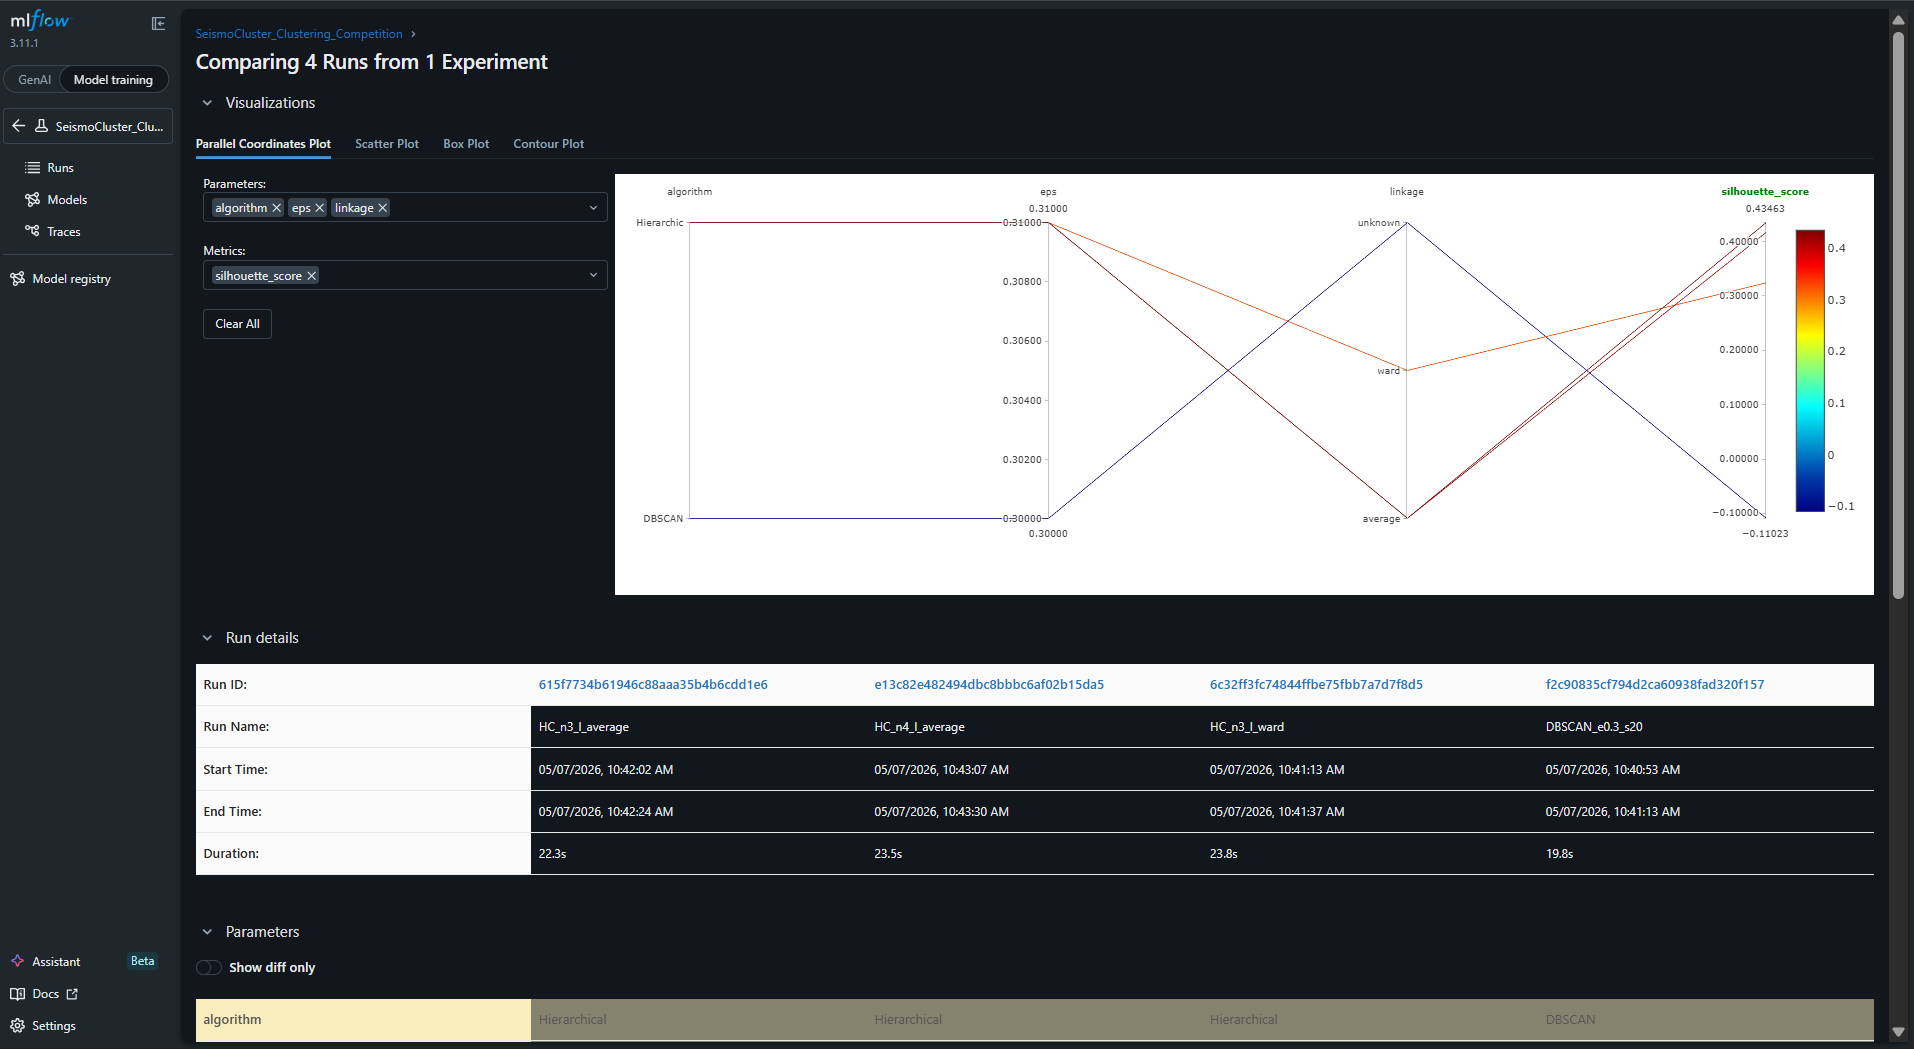

**Uji coba Hierarchical**

Melakukan otomatisasi pencarian parameter optimal untuk n_clusters (jumlah zona) dan linkage (kriteria penggabungan) guna melihat struktur hubungan bertingkat antar wilayah gempa. Model ini bekerja dengan cara menggabungkan klaster kecil menjadi klaster besar secara bertahap dengan melihat struktur hubungan.

In [9]:
# 1. SETUP EXPERIMENT
# Kita tetap menggunakan arena kompetisi yang sama agar mudah dibandingkan di UI
mlflow.set_experiment("SeismoCluster_Clustering_Competition")

print("Memulai Hyperparameter Tuning untuk Hierarchical Clustering...")
print("-" * 50)

# 2. DEFINISI RUANG PARAMETER (Hyperparameter Grid)
# n_clusters: Jumlah zona yang ingin dibentuk
# linkage: Metode untuk menghitung jarak antar kelompok saat digabungkan
param_grid_hc = {
    "n_clusters": [3, 4, 5, 6],
    "linkage": ["ward", "complete", "average"]
}

# Membuat semua kombinasi pasangan n_clusters dan linkage
combinations_hc = list(itertools.product(param_grid_hc["n_clusters"], param_grid_hc["linkage"]))

# 3. LOOPING EKSPERIMEN OTOMATIS (Sesuai instruksi tugas dosen)
for n_clusters, linkage in combinations_hc:
    # Membuka sesi run dengan nama yang deskriptif untuk setiap kombinasi
    with mlflow.start_run(run_name=f"HC_n{n_clusters}_l_{linkage}"):
        
        # --- A. TRAINING MODEL ---
        # AgglomerativeClustering adalah metode Hierarchical paling populer
        hc = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = hc.fit_predict(X_scaled)
        
        # --- B. EVALUASI METRIK (Sesuai tabel rencana Anda) ---
        sil_score = silhouette_score(X_scaled, labels)
        db_score = davies_bouldin_score(X_scaled, labels)
        ch_score = calinski_harabasz_score(X_scaled, labels)
        
        # --- C. LOGGING KE MLFLOW ---
        mlflow.log_param("algorithm", "Hierarchical")
        mlflow.log_param("n_clusters", n_clusters)
        mlflow.log_param("linkage", linkage)
        
        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("davies_bouldin_index", db_score)
        mlflow.log_metric("calinski_harabasz", ch_score)
        
        # --- D. SAVE ARTIFACT (Log Model) ---
        mlflow.sklearn.log_model(hc, "model")
        
        print(f"n={n_clusters} | Linkage: {linkage:8} | Silh: {sil_score:.4f} | DB Index: {db_score:.4f}")

print("-" * 50)
print("Tuning Hierarchical Clustering Selesai! Semua data riset tersimpan di MLflow.")

Memulai Hyperparameter Tuning untuk Hierarchical Clustering...
--------------------------------------------------


2026/05/08 08:57:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:57:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 08:57:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


n=3 | Linkage: ward     | Silh: 0.3237 | DB Index: 1.2241
🏃 View run HC_n3_l_ward at: http://localhost:5000/#/experiments/2/runs/c881e92dcfad4f4eba347eb84a164e40
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/08 08:58:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 08:58:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 08:58:01 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


n=3 | Linkage: complete | Silh: 0.2599 | DB Index: 1.2117
🏃 View run HC_n3_l_complete at: http://localhost:5000/#/experiments/2/runs/9ab174e1a97f475c84cc1e099f37f061
🧪 View experiment at: http://localhost:5000/#/experiments/2


...

n=6 | Linkage: ward     | Silh: 0.2980 | DB Index: 1.0399
🏃 View run HC_n6_l_ward at: http://localhost:5000/#/experiments/2/runs/dbea81aeee934f0fb8e2347b91cfe72a
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/08 09:01:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 09:01:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 09:01:41 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


n=6 | Linkage: complete | Silh: 0.1791 | DB Index: 1.1198
🏃 View run HC_n6_l_complete at: http://localhost:5000/#/experiments/2/runs/03b5cd5619654c14ad53e5982b43df49
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/08 09:02:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 09:02:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 09:02:16 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


n=6 | Linkage: average  | Silh: 0.2748 | DB Index: 0.8752
🏃 View run HC_n6_l_average at: http://localhost:5000/#/experiments/2/runs/6b81e647f8814cf08b2c082bfff399cb
🧪 View experiment at: http://localhost:5000/#/experiments/2
--------------------------------------------------
Tuning Hierarchical Clustering Selesai! Semua data riset tersimpan di MLflow.


![Cuplikan layar 2026-05-07 111831.png](<attachment:Cuplikan layar 2026-05-07 111831.png>)

Hierarchical Clustering memiliki nilai sillhoutte tertinggi dari model clustering sebelumnya. Meskipun menggunakan 4D model ini tetap mampu merangkai hirearki kemiripan gempa (baik dari letak, kedalaman, maupun kekuatan) dengan paling seimbang, sehingga mencetak skor tertinggi (0.435).

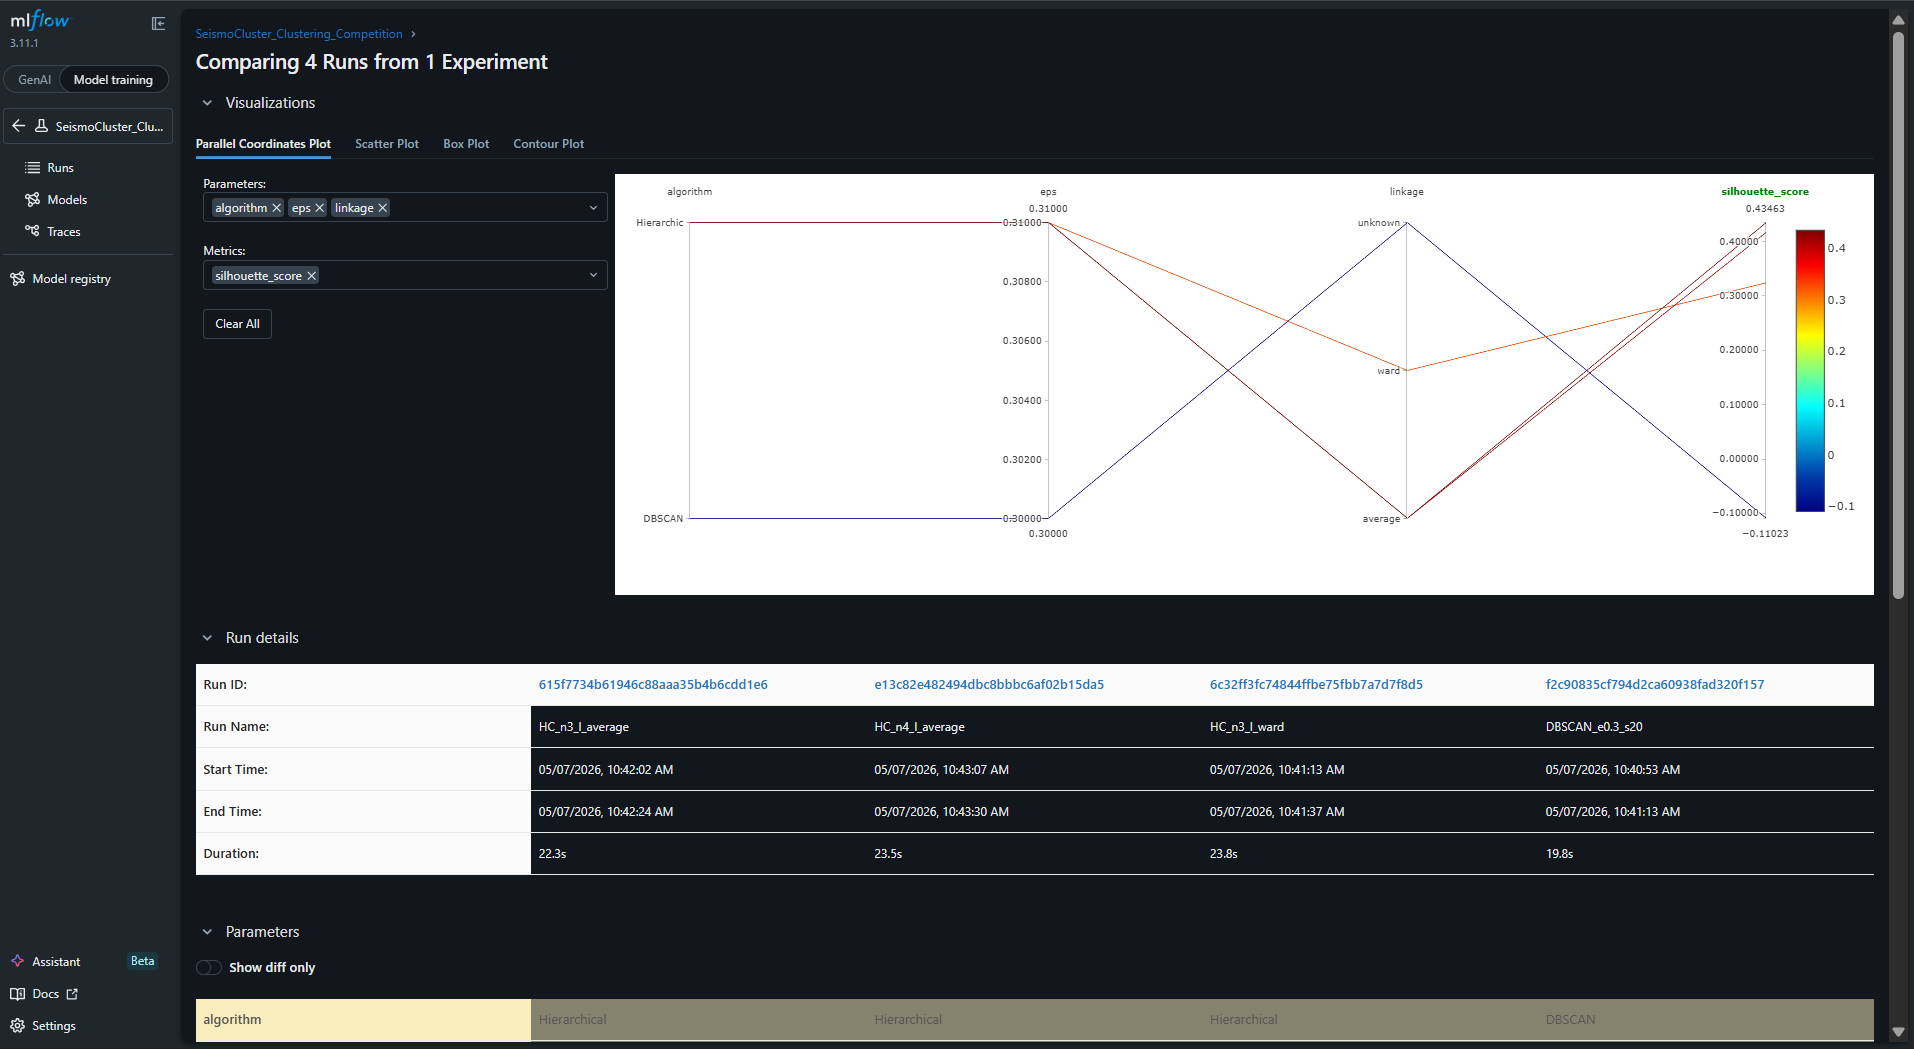

**Uji Coba Isolation Forest**

Mengotomatiskan pencarian parameter n_estimators (jumlah pohon evaluasi) dan contamination (estimasi persentase gempa tidak wajar) untuk menemukan model yang paling pas dalam mendeteksi kejadian gempa ekstrem (berdasarkan kombinasi kedalaman, magnitudo, dan lokasi).

In [10]:
# 1. SETUP EXPERIMENT (Divisi Anomali)
mlflow.set_experiment("SeismoCluster_Anomaly_Detection")

print("Memulai Hyperparameter Tuning untuk Isolation Forest...")
print("-" * 50)

# 2. DEFINISI RUANG PARAMETER (Hyperparameter Grid)
# n_estimators: Jumlah "pohon keputusan" untuk mengisolasi titik anomali
# contamination: Estimasi persentase titik yang dianggap anomali/ekstrem
param_grid_if = {
    "n_estimators": [50, 100, 200],
    "contamination": [0.01, 0.05, 0.1] # Menguji skenario anomali 1%, 5%, dan 10%
}

combinations_if = list(itertools.product(param_grid_if["n_estimators"], param_grid_if["contamination"]))

# 3. LOOPING EKSPERIMEN OTOMATIS
for n_trees, contam in combinations_if:
    # Nama run yang rapi agar mudah dilacak di UI
    with mlflow.start_run(run_name=f"IF_trees{n_trees}_cont{contam}"):
        
        # --- A. TRAINING MODEL ---
        # n_jobs=-1 memastikan algoritma menggunakan seluruh core CPU agar komputasi kilat
        iso_forest = IsolationForest(n_estimators=n_trees, 
                                     contamination=contam, 
                                     random_state=42, 
                                     n_jobs=-1)
        
        # Prediksi: 1 = Gempa Normal, -1 = Gempa Anomali (Ekstrem)
        labels = iso_forest.fit_predict(X_scaled)
        
        # --- B. EVALUASI METRIK BISNIS ---
        # Menghitung berapa banyak anomali yang berhasil ditangkap
        n_anomalies = list(labels).count(-1)
        n_normal = list(labels).count(1)
        anomaly_percentage = (n_anomalies / len(labels)) * 100
        
        # --- C. LOGGING PARAMETER & METRIK KE MLFLOW ---
        mlflow.log_param("algorithm", "Isolation_Forest")
        mlflow.log_param("n_estimators", n_trees)
        mlflow.log_param("contamination", contam)
        
        mlflow.log_metric("n_anomalies_detected", n_anomalies)
        mlflow.log_metric("n_normal_detected", n_normal)
        mlflow.log_metric("anomaly_percentage_actual", anomaly_percentage)
        
        # --- D. SAVE ARTIFACT (Simpan Model Fisik) ---
        mlflow.sklearn.log_model(iso_forest, "model")
        
        print(f"Trees: {n_trees:3} | Contam: {contam:4} | Anomali Terdeteksi: {n_anomalies} titik ({anomaly_percentage:.1f}%)")

print("-" * 50)
print("Tuning Isolation Forest Selesai! Arena deteksi anomali siap diinspeksi di MLflow UI.")

2026/05/08 09:02:29 INFO mlflow.tracking.fluent: Experiment with name 'SeismoCluster_Anomaly_Detection' does not exist. Creating a new experiment.


Memulai Hyperparameter Tuning untuk Isolation Forest...
--------------------------------------------------


2026/05/08 09:02:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 09:02:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Trees:  50 | Contam: 0.01 | Anomali Terdeteksi: 125 titik (1.0%)
🏃 View run IF_trees50_cont0.01 at: http://localhost:5000/#/experiments/3/runs/deccef3f9c2d49d2a9e78432ae11ce53
🧪 View experiment at: http://localhost:5000/#/experiments/3


2026/05/08 09:02:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 09:02:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Trees: 200 | Contam: 0.01 | Anomali Terdeteksi: 125 titik (1.0%)
🏃 View run IF_trees200_cont0.01 at: http://localhost:5000/#/experiments/3/runs/eae6b2f395b042e381e2ff08f6a00131
🧪 View experiment at: http://localhost:5000/#/experiments/3


2026/05/08 09:03:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 09:03:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Trees: 200 | Contam: 0.05 | Anomali Terdeteksi: 625 titik (5.0%)
🏃 View run IF_trees200_cont0.05 at: http://localhost:5000/#/experiments/3/runs/3929951db5034428b94be1b2d9d94e3c
🧪 View experiment at: http://localhost:5000/#/experiments/3


2026/05/08 09:03:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 09:03:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Trees: 200 | Contam:  0.1 | Anomali Terdeteksi: 1249 titik (10.0%)
🏃 View run IF_trees200_cont0.1 at: http://localhost:5000/#/experiments/3/runs/0701b6fb4cc043d4a7726fa970c05cf7
🧪 View experiment at: http://localhost:5000/#/experiments/3
--------------------------------------------------
Tuning Isolation Forest Selesai! Arena deteksi anomali siap diinspeksi di MLflow UI.


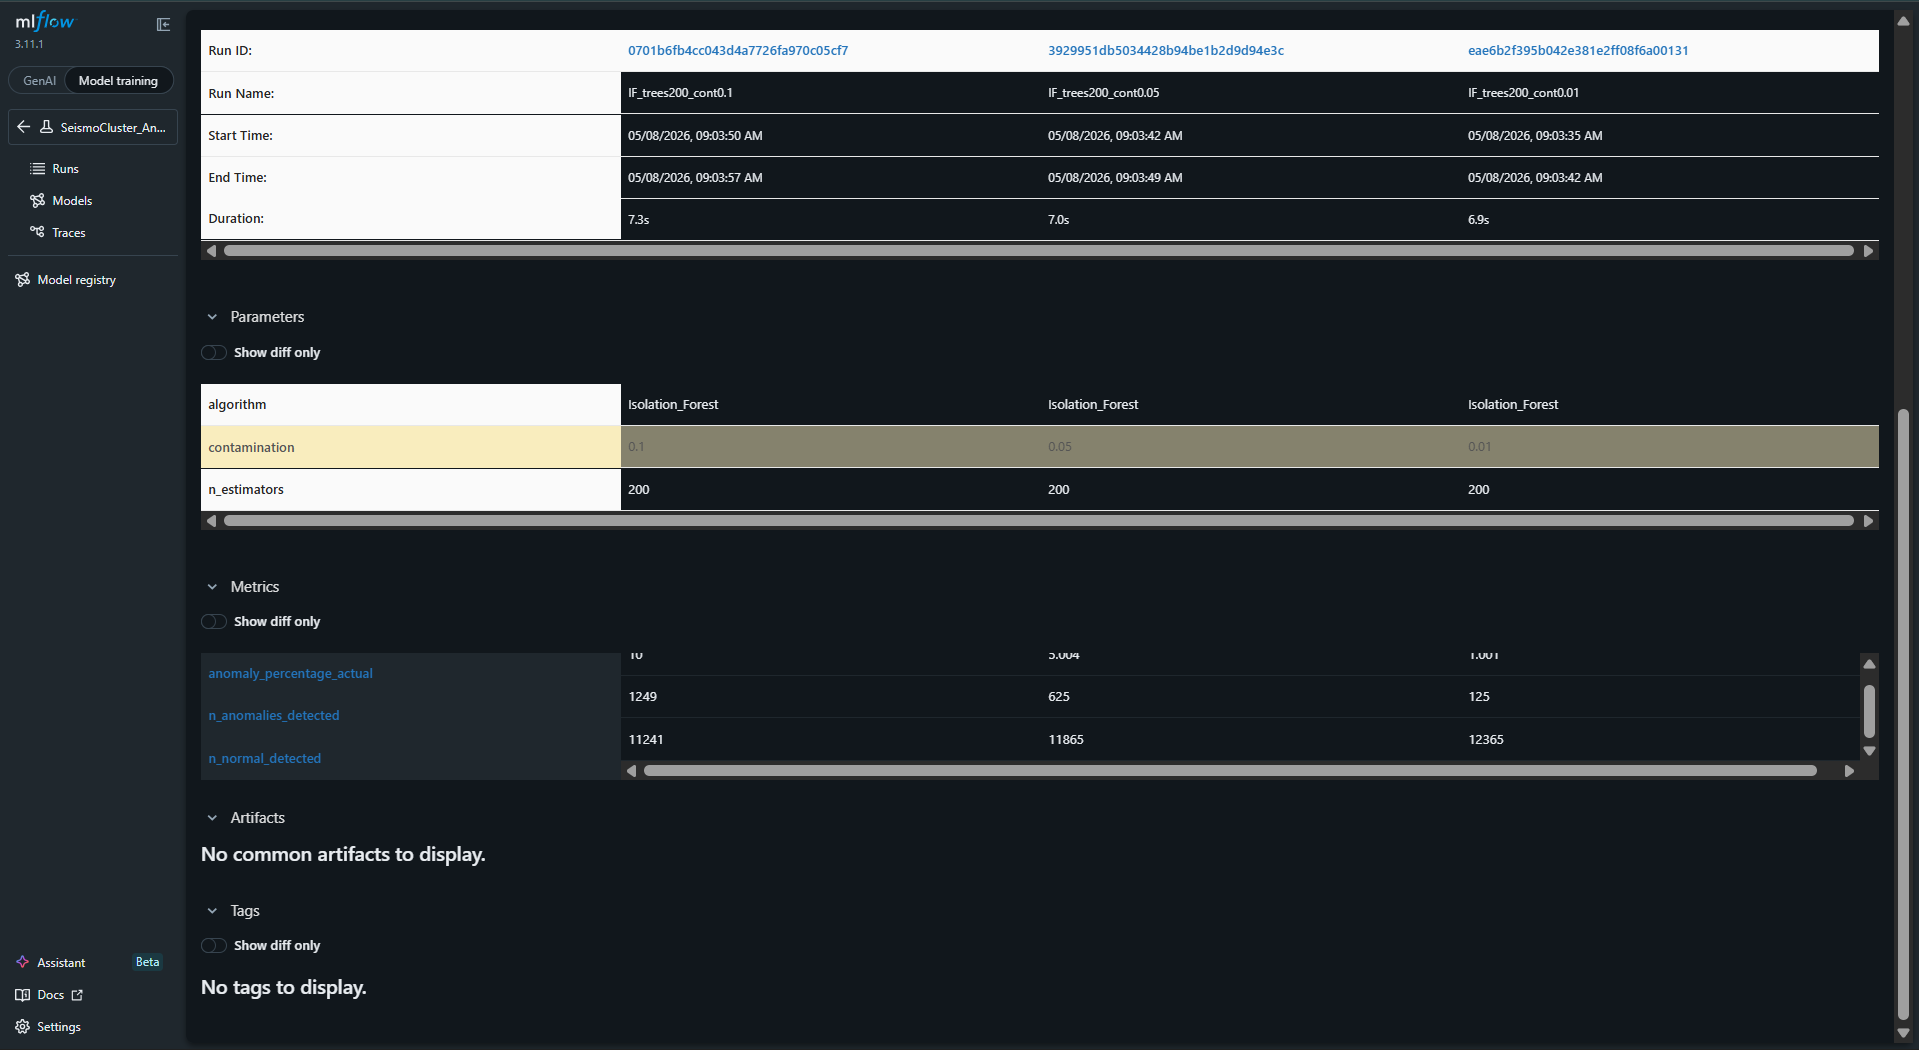

Untuk divisi deteksi anomali, evaluasi dilakukan pada model Isolation Forest (n_estimators=200) dengan tiga skenario contamination (10%, 5%, dan 1%). Berdasarkan hasil tracking di MLflow, skenario 10% terdeteksi memunculkan 1.249 anomali, yang secara operasional mitigasi bencana berisiko memicu alarm fatigue (false alarm berlebih). Oleh karena itu, skenario contamination 1% (Model IF_trees200_cont0.01) ditetapkan sebagai model produksi.